## this notebook conains first shape tests and then volatility tests

#### Calculating betas for historical data
for lambda = 0.0609


other values ( 0.0074 : 20y maturity)

Historical: 232 monthly observations
Historical betas shape: (232, 3)
Simulated betas shape: (12000, 3)
Plot saved.

=== Beta Summary ===

beta1 (Level)
  Historical: mean=3.8872  std=1.2133  min=1.1389  max=6.2272
  Simulated:  mean=4.6755  std=0.1752  min=3.8054  max=5.4269

beta2 (Slope)
  Historical: mean=-2.5705  std=1.5472  min=-5.1687  max=0.7164
  Simulated:  mean=-0.9037  std=0.3280  min=-3.4502  max=0.1723

beta3 (Curvature)
  Historical: mean=-3.1544  std=2.1160  min=-7.3461  max=0.7381
  Simulated:  mean=-3.5407  std=0.6658  min=-7.1720  max=-0.5584


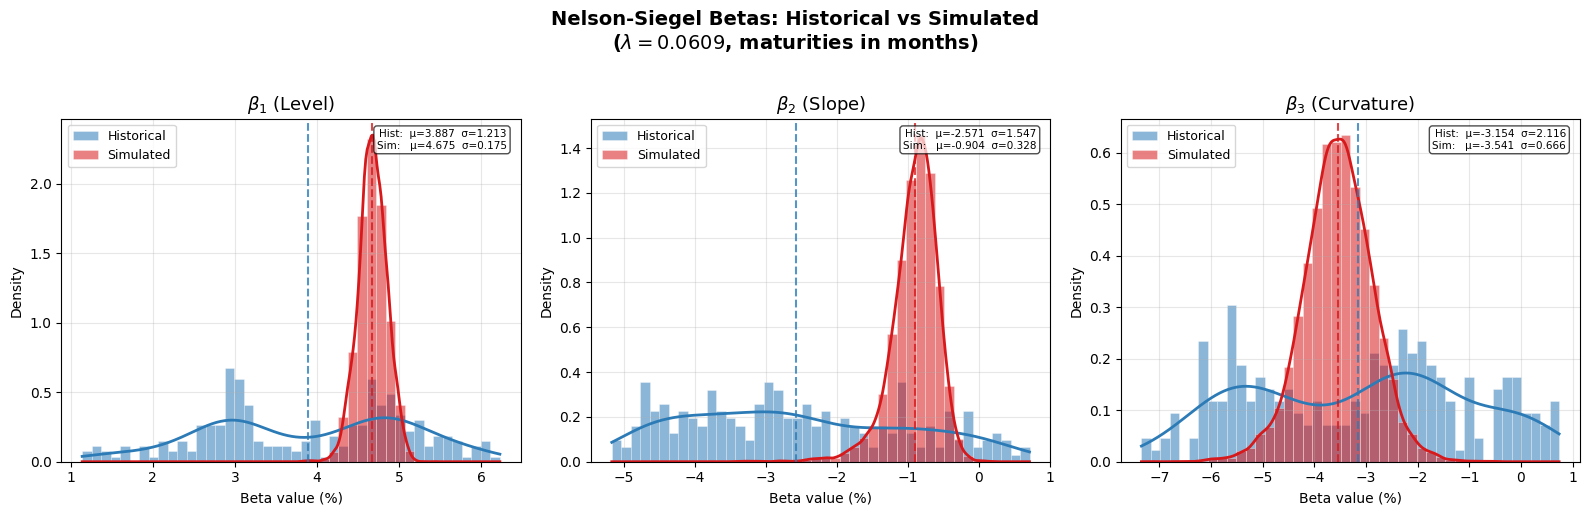

In [41]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Nelson-Siegel setup ─────────────────────────────────────────────────────
LAMBDA = 0.0609  # global lambda (monthly units)

# Maturities in years → convert to months
HIST_MATS_YR   = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
HIST_MATS_MO   = HIST_MATS_YR * 12

SIM_MATS_YR    = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
SIM_MATS_MO    = SIM_MATS_YR * 12

def ns_loadings(tau, lam):
    """Returns (N,3) matrix of NS factor loadings for maturities tau (months)."""
    lt = lam * tau
    L1 = np.ones_like(lt)
    L2 = (1 - np.exp(-lt)) / lt
    L3 = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])

def fit_ns_ols(yields, tau, lam):
    """Fit Nelson-Siegel betas by OLS (closed-form)."""
    X = ns_loadings(tau, lam)
    # OLS: beta = (X'X)^-1 X'y
    betas, _, _, _ = np.linalg.lstsq(X, yields, rcond=None)
    return betas  # [beta0, beta1, beta2]

# ── 1. Historical data → monthly ────────────────────────────────────────────
hist_cols = ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y',
             'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']

hist = pd.read_csv('historical data train.csv', parse_dates=['DATE'])
hist = hist.set_index('DATE')[hist_cols]

# Resample to month-end (last observation of each month)
hist_monthly = hist.resample('ME').last()
print(f"Historical: {len(hist_monthly)} monthly observations")

# Fit NS for each month
hist_betas = []
for idx, row in hist_monthly.iterrows():
    b = fit_ns_ols(row.values, HIST_MATS_MO, LAMBDA)
    hist_betas.append(b)
hist_betas = np.array(hist_betas)   # shape (T, 3)
print(f"Historical betas shape: {hist_betas.shape}")

# ── 2. Simulated data ────────────────────────────────────────────────────────
sim_yield_cols = ['Y_1M', 'Y_3M', 'Y_6M', 'Y_1Y', 'Y_2Y', 'Y_3Y', 'Y_5Y', 'Y_7Y',
                  'Y_10Y', 'Y_20Y', 'Y_30Y']

sim = pd.read_csv('mvp1_simulated_paths.csv')

sim_betas = []
for _, row in sim.iterrows():
    b = fit_ns_ols(row[sim_yield_cols].values, SIM_MATS_MO, LAMBDA)
    sim_betas.append(b)
sim_betas = np.array(sim_betas)   # shape (12000, 3)
print(f"Simulated betas shape: {sim_betas.shape}")

# ── 3. Plotting ──────────────────────────────────────────────────────────────
beta_labels = [
    r'$\beta_1$ (Level)',
    r'$\beta_2$ (Slope)',
    r'$\beta_3$ (Curvature)'
]
colors_hist = '#2c7bb6'
colors_sim  = '#d7191c'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Nelson-Siegel Betas: Historical vs Simulated\n'
             r'($\lambda = 0.0609$, maturities in months)',
             fontsize=14, fontweight='bold', y=1.02)

for i, (ax, label) in enumerate(zip(axes, beta_labels)):
    h_vals = hist_betas[:, i]
    s_vals = sim_betas[:, i]

    # Determine common bin range
    lo = min(h_vals.min(), s_vals.min())
    hi = max(h_vals.max(), s_vals.max())
    bins = np.linspace(lo, hi, 45)

    ax.hist(h_vals, bins=bins, density=True, alpha=0.55,
            color=colors_hist, label='Historical', edgecolor='white', linewidth=0.4)
    ax.hist(s_vals, bins=bins, density=True, alpha=0.55,
            color=colors_sim,  label='Simulated',  edgecolor='white', linewidth=0.4)

    # Add KDE lines
    from scipy.stats import gaussian_kde
    x_grid = np.linspace(lo, hi, 300)
    for vals, color in [(h_vals, colors_hist), (s_vals, colors_sim)]:
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)

    # Summary stats
    ax.axvline(h_vals.mean(), color=colors_hist, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axvline(s_vals.mean(), color=colors_sim,  linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Beta value (%)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Text box with stats
    stats_txt = (f"Hist:  μ={h_vals.mean():.3f}  σ={h_vals.std():.3f}\n"
                 f"Sim:   μ={s_vals.mean():.3f}  σ={s_vals.std():.3f}")
    ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
#plt.savefig('ns_beta_distributions.png', dpi=160, bbox_inches='tight')
print("Plot saved.")

# ── 4. Print summary table ───────────────────────────────────────────────────
print("\n=== Beta Summary ===")
for i, name in enumerate(['beta1 (Level)', 'beta2 (Slope)', 'beta3 (Curvature)']):
    h, s = hist_betas[:, i], sim_betas[:, i]
    print(f"\n{name}")
    print(f"  Historical: mean={h.mean():.4f}  std={h.std():.4f}  "
          f"min={h.min():.4f}  max={h.max():.4f}")
    print(f"  Simulated:  mean={s.mean():.4f}  std={s.std():.4f}  "
          f"min={s.min():.4f}  max={s.max():.4f}")

In [42]:
from scipy.stats import wasserstein_distance
import pandas as pd
import numpy as np

# =========================
# FUNCTION
# =========================
def compute_wasserstein(hist_betas, sim_betas):
    results = []

    names = ["Level (β1)", "Slope (β2)", "Curvature (β3)"]

    for i, name in enumerate(names):
        h = hist_betas[:, i]
        s = sim_betas[:, i]

        w = wasserstein_distance(h, s)

        results.append({
            "Beta": name,
            "Wasserstein Distance": w,
            "Hist Mean": np.mean(h),
            "Sim Mean": np.mean(s),
            "Hist Std": np.std(h),
            "Sim Std": np.std(s)
        })

    return pd.DataFrame(results)

# =========================
# RUN
# =========================
comparison = compute_wasserstein(hist_betas, sim_betas)

print("\n=== Wasserstein Comparison ===")
print(comparison)


=== Wasserstein Comparison ===
             Beta  Wasserstein Distance  Hist Mean  Sim Mean  Hist Std  \
0      Level (β1)              1.020874   3.887218  4.675469  1.213318   
1      Slope (β2)              1.791529  -2.570515 -0.903655  1.547219   
2  Curvature (β3)              1.370964  -3.154369 -3.540731  2.116042   

    Sim Std  
0  0.175191  
1  0.327983  
2  0.665800  


same but using PCA

Historical monthly obs: 232
  PC1: 84.14%
  PC2: 14.77%
  PC3: 0.86%
  Total: 99.78%
Hist scores: (232, 3), Sim scores: (12000, 3)
Plot saved.

=== PCA Loadings ===
Maturity           PC1       PC2       PC3
Yield_1M        0.2973   -0.3161   -0.3986
Yield_3M        0.2997   -0.3119   -0.3127
Yield_6M        0.3027   -0.3005   -0.1948
Yield_1Y        0.3087   -0.2667   -0.0127
Yield_2Y        0.3190   -0.1718    0.2807
Yield_3Y        0.3241   -0.0798    0.4126
Yield_5Y        0.3236    0.0960    0.3951
Yield_7Y        0.3138    0.2199    0.2771
Yield_10Y       0.2988    0.3250    0.0227
Yield_20Y       0.2672    0.4503   -0.2655
Yield_30Y       0.2532    0.4894   -0.3902


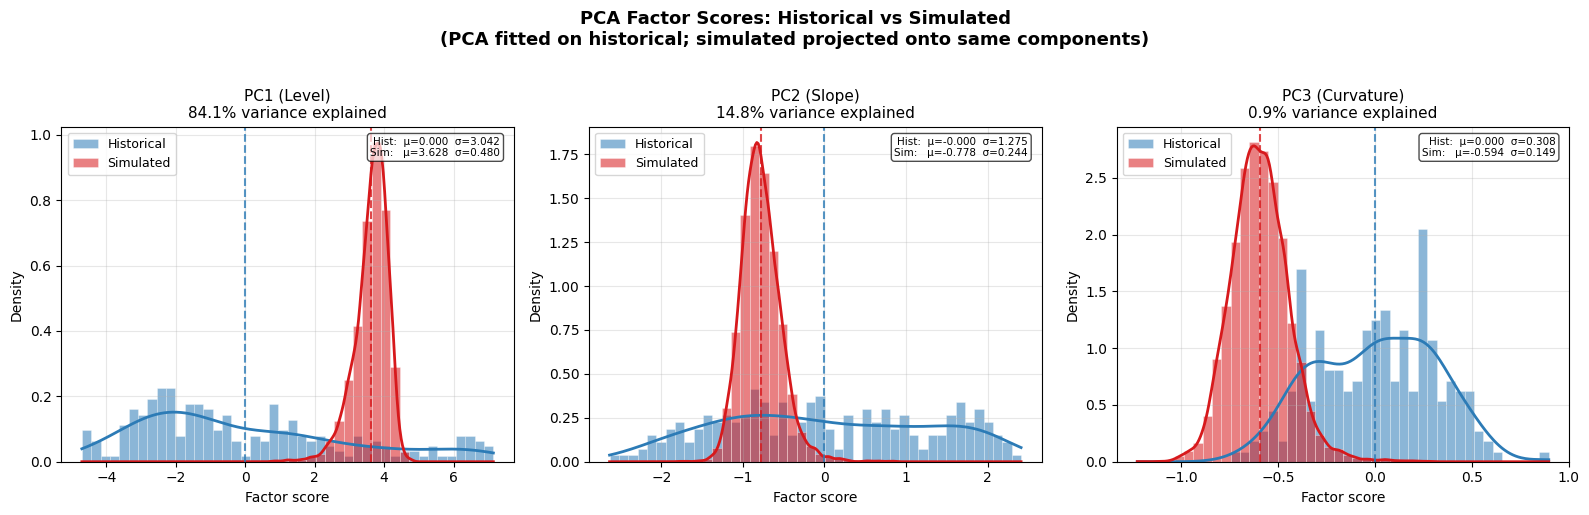

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

# ── 1. Historical monthly data ───────────────────────────────────────────────
hist_cols = ['Yield_1M','Yield_3M','Yield_6M','Yield_1Y','Yield_2Y',
             'Yield_3Y','Yield_5Y','Yield_7Y','Yield_10Y','Yield_20Y','Yield_30Y']

hist = pd.read_csv('historical data train.csv', parse_dates=['DATE'])
hist = hist.set_index('DATE')[hist_cols].resample('ME').last()
print(f"Historical monthly obs: {len(hist)}")

# ── 2. Fit PCA on historical ─────────────────────────────────────────────────
scaler = StandardScaler()
hist_scaled = scaler.fit_transform(hist.values)

pca = PCA(n_components=3)
pca.fit(hist_scaled)

for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.2f}%")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# ── 3. Project both datasets onto same PCA components ────────────────────────
hist_scores = pca.transform(hist_scaled)

sim_yield_cols = ['Y_1M','Y_3M','Y_6M','Y_1Y','Y_2Y','Y_3Y','Y_5Y','Y_7Y','Y_10Y','Y_20Y','Y_30Y']
sim = pd.read_csv('mvp1_simulated_paths.csv')
sim_scaled = scaler.transform(sim[sim_yield_cols].values)  # same scaler!
sim_scores = pca.transform(sim_scaled)                     # same components!
print(f"Hist scores: {hist_scores.shape}, Sim scores: {sim_scores.shape}")

# ── 4. Plot distributions ─────────────────────────────────────────────────────
labels = [
    f'PC1 (Level)\n{pca.explained_variance_ratio_[0]*100:.1f}% variance explained',
    f'PC2 (Slope)\n{pca.explained_variance_ratio_[1]*100:.1f}% variance explained',
    f'PC3 (Curvature)\n{pca.explained_variance_ratio_[2]*100:.1f}% variance explained',
]
C_HIST, C_SIM = '#2c7bb6', '#d7191c'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PCA Factor Scores: Historical vs Simulated\n'
             '(PCA fitted on historical; simulated projected onto same components)',
             fontsize=13, fontweight='bold', y=1.02)

for i, (ax, label) in enumerate(zip(axes, labels)):
    h, s = hist_scores[:, i], sim_scores[:, i]
    lo = min(h.min(), s.min())
    hi = max(h.max(), s.max())
    bins = np.linspace(lo, hi, 45)
    x_grid = np.linspace(lo, hi, 300)

    ax.hist(h, bins=bins, density=True, alpha=0.55, color=C_HIST,
            label='Historical', edgecolor='white', lw=0.4)
    ax.hist(s, bins=bins, density=True, alpha=0.55, color=C_SIM,
            label='Simulated',  edgecolor='white', lw=0.4)
    for vals, c in [(h, C_HIST), (s, C_SIM)]:
        ax.plot(x_grid, gaussian_kde(vals, bw_method='scott')(x_grid), color=c, lw=2)
    ax.axvline(h.mean(), color=C_HIST, ls='--', lw=1.5, alpha=0.8)
    ax.axvline(s.mean(), color=C_SIM,  ls='--', lw=1.5, alpha=0.8)

    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Factor score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.text(0.97, 0.97,
            f"Hist:  μ={h.mean():.3f}  σ={h.std():.3f}\nSim:   μ={s.mean():.3f}  σ={s.std():.3f}",
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
# plt.savefig('pca_factor_distributions.png', dpi=160, bbox_inches='tight')
print("Plot saved.")

# ── 5. Loadings table ────────────────────────────────────────────────────────
print("\n=== PCA Loadings ===")
header = f"{'Maturity':<12}" + "".join([f"{'PC'+str(i+1):>10}" for i in range(3)])
print(header)
for mat, row in zip(hist_cols, pca.components_.T):
    line = f"{mat:<12}" + "".join([f"{v:>10.4f}" for v in row])
    print(line)

Calculating lambda attempts

In [15]:
import numpy as np
import pandas as pd

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("historical data train.csv")

# Try to detect date column automatically
for col in df.columns:
    if "date" in col.lower():
        df[col] = pd.to_datetime(df[col])
        df = df.set_index(col)
        break

# =========================
# 2. CONVERT TO MONTHLY (SAFE)
# =========================
try:
    df = df.resample('M').mean()
except:
    # if no datetime index → skip
    pass

# =========================
# 3. DETECT YIELD COLUMNS AUTOMATICALLY
# =========================
# We assume columns contain something like "1M", "3M", "1Y", etc.

maturity_map = {
    "1m": 1/12,
    "3m": 3/12,
    "6m": 6/12,
    "1y": 1,
    "2y": 2,
    "3y": 3,
    "5y": 5,
    "7y": 7,
    "10y": 10
}

selected_cols = []
tau = []

for col in df.columns:
    c = col.lower()
    for key in maturity_map:
        if key in c:
            selected_cols.append(col)
            tau.append(maturity_map[key])
            break

# Sort by maturity
tau = np.array(tau)
selected_cols = np.array(selected_cols)

order = np.argsort(tau)
tau = tau[order]
selected_cols = selected_cols[order]

# Keep only up to 10Y (avoid distortion)
mask = tau <= 10
tau = tau[mask]
selected_cols = selected_cols[mask]

# Extract data
Y = df[selected_cols].values.astype(float)

print("\nUsing maturities:", tau)

# =========================
# 4. FIND BELLY (CURVATURE)
# =========================
curvature_strength = []

for i in range(1, len(tau)-1):
    short = Y[:, i-1]
    mid   = Y[:, i]
    long  = Y[:, i+1]

    curv = 2*mid - short - long

    strength = np.nanmean(np.abs(curv))

    curvature_strength.append((tau[i], strength))

# Find best belly
best_tau, best_strength = max(curvature_strength, key=lambda x: x[1])

print("\n===== RESULT =====")
print(f"Best belly maturity: {best_tau:.2f} years")

# =========================
# 5. COMPUTE LAMBDA
# =========================
lam_star = 1.78 / best_tau

print(f"Lambda (from belly): {lam_star:.4f}")

# =========================
# 6. DEBUG OUTPUT (IMPORTANT)
# =========================
print("\nAll curvature strengths:")
for t, s in curvature_strength:
    print(f"{t:.2f} years → {s:.6f}")


Using maturities: [ 0.08333333  0.25        0.5         1.          2.          3.
  5.          7.         10.        ]

===== RESULT =====
Best belly maturity: 3.00 years
Lambda (from belly): 0.5933

All curvature strengths:
0.25 years → 0.060346
0.50 years → 0.083183
1.00 years → 0.147946
2.00 years → 0.075792
3.00 years → 0.223184
5.00 years → 0.125001
7.00 years → 0.082088


/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_28126/2280539605.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample('M').mean()


In [9]:
from scipy.optimize import minimize_scalar
import numpy as np

def ns_loadings(tau, lam):
    L1 = np.ones_like(tau)
    L2 = (1 - np.exp(-lam * tau)) / (lam * tau)
    L3 = L2 - np.exp(-lam * tau)
    return np.column_stack([L1, L2, L3])

def fit_ns(yields_row, tau, lam):
    X     = ns_loadings(tau, lam)
    betas = np.linalg.lstsq(X, yields_row, rcond=None)[0]
    rmse  = np.sqrt(np.mean((X @ betas - yields_row)**2))
    return betas, rmse

def total_rmse(lam, yields_matrix, tau):
    return np.mean([fit_ns(row, tau, lam)[1] for row in yields_matrix])

# Maturities in years
tau = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])

# Step 1: optimise λ on historical data only
result   = minimize_scalar(total_rmse,
                           args=(hist_yields_matrix, tau),
                           bounds=(0.01, 1.0),
                           method='bounded')
lam_star = result.x
print(f"Optimal λ: {lam_star:.4f}")

# Step 2: fit historical
hist_betas = np.array([fit_ns(row, tau, lam_star)[0]
                       for row in hist_yields_matrix])

# Step 3: fit simulated
sim_betas  = np.array([fit_ns(row, tau, lam_star)[0]
                       for row in sim_yields_matrix])

# Step 4: compare β₂ and β₃

Optimal λ: 0.4853


NameError: name 'sim_yields_matrix' is not defined

In [16]:
import numpy as np
import pandas as pd

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("historical data train.csv")

# detect date column (optional)
for col in df.columns:
    if "date" in col.lower():
        df[col] = pd.to_datetime(df[col])
        df = df.set_index(col)
        break

# monthly average (safe)
try:
    df = df.resample('M').mean()
except:
    pass

# =========================
# 2. DEFINE MATURITIES (EDIT IF NEEDED)
# =========================
cols = ['Yield_1M','Yield_3M','Yield_6M','Yield_1Y',
        'Yield_2Y','Yield_3Y','Yield_5Y','Yield_7Y','Yield_10Y']

tau = np.array([1/12,3/12,6/12,1,2,3,5,7,10])

Y = df[cols].values.astype(float)

# =========================
# 3. COMPUTE CURVATURE
# =========================
curvature_scores = []

for i in range(1, len(tau)-1):
    short = Y[:, i-1]
    mid   = Y[:, i]
    long  = Y[:, i+1]

    # curvature
    curv = 2*mid - short - long

    # strength = average absolute curvature
    score = np.nanmean(np.abs(curv))

    curvature_scores.append((tau[i], score))

# =========================
# 4. FIND BELLY
# =========================
best_tau, best_score = max(curvature_scores, key=lambda x: x[1])

print("\n===== YOUR BELLY =====")
print(f"Belly maturity: {best_tau:.2f} years")

# =========================
# 5. COMPUTE LAMBDA
# =========================
lam_star = 1.78 / best_tau

print(f"Lambda from your data: {lam_star:.4f}")


===== YOUR BELLY =====
Belly maturity: 3.00 years
Lambda from your data: 0.5933


/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_28126/3934060482.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample('M').mean()


In [28]:
x = 0.5933/12
print(x)

0.04944166666666667
